In [1]:
import matplotlib.pyplot as plt
import numpy as np
from ngsolve import GridFunction
import ipywidgets as widgets
from ipywidgets import interact
from pymor.core.pickle import load

from fom import create_fom

fom = create_fom(nt=300, h=50, time=30)

print(fom)

# access parameter study
with open('brusselator_parameters.pkl', 'rb') as f:
    parameterstudy = load(f)

# access snapshots
with open('brusselator_snapshots.pkl', 'rb') as f:
    alte_snapshots = load(f)
std_snapshots = fom.solution_space.from_numpy(alte_snapshots.to_numpy())

# access customized snapshots
with open('customized_brusselator_snapshots.pkl', 'rb') as f:
    alte_snapshots1 = load(f)
customized_snapshots = fom.solution_space.from_numpy(alte_snapshots1.to_numpy())
 
# access curly_U snapshots
with open('curly_U_snapshots.pkl', 'rb') as f: 
    alte_snapshots2 = load(f)
curly_U_DtDa = fom.solution_space.from_numpy(alte_snapshots2.to_numpy()) 

# access curly_U_DaDt snapshots
with open('curly_U_DaDt_snapshots.pkl', 'rb') as f: 
    alte_snapshots3 = load(f)
curly_U_DaDt = fom.solution_space.from_numpy(alte_snapshots3.to_numpy())
 

InstationaryModel
    class: InstationaryModel
    non-linear
    T: 30
    solution_space:  NGSolveVectorSpace(<ngsolve.comp.ProductSpace object at 0x000001D23952F2F0>)
    dim_input:       0
    dim_output:      0


In [2]:
len(customized_snapshots), len(std_snapshots), len(curly_U_DtDa), len(curly_U_DaDt)

(260, 260, 260, 260)

In [3]:
# POD with std 
r_std = 60

from pymor.algorithms.pod import pod
std_pod_basis, std_pod_singular_values = pod(std_snapshots,
                                     product=fom.products['h1_0_semi'],
                                     modes=r_std,
                                     rtol=1e-12,   
                                     atol=0.0 
                                    )
len(std_pod_basis)

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

60

In [4]:
# POD with std, customized
r_std = 60

from pymor.algorithms.pod import pod
customized_pod_basis, customized_pod_singular_values = pod(customized_snapshots,
                                     product=fom.products['h1_0_semi'],
                                     modes=r_std,  
                                     rtol=1e-12,   
                                     atol=0.0 
                                    )
len(customized_pod_basis)

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

60

In [5]:
# POD with curly U DtDa

r_std = 60

from pymor.algorithms.pod import pod
U_DtDa_pod_basis, U_DtDa_pod_singular_values = pod(curly_U_DtDa,
                                     product=fom.products['h1_0_semi'],
                                     modes=r_std,  
                                     rtol=1e-12,   
                                     atol=0.0 
                                    )
len(U_DtDa_pod_basis)

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

60

In [6]:
# POD with curly U DaDt

r_std = 60

from pymor.algorithms.pod import pod
U_DaDt_pod_basis, U_DaDt_pod_singular_values = pod(curly_U_DaDt,
                                     product=fom.products['h1_0_semi'],
                                     modes=r_std,  
                                     rtol=1e-12,   
                                     atol=0.0 
                                    )
len(U_DaDt_pod_basis)

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

60

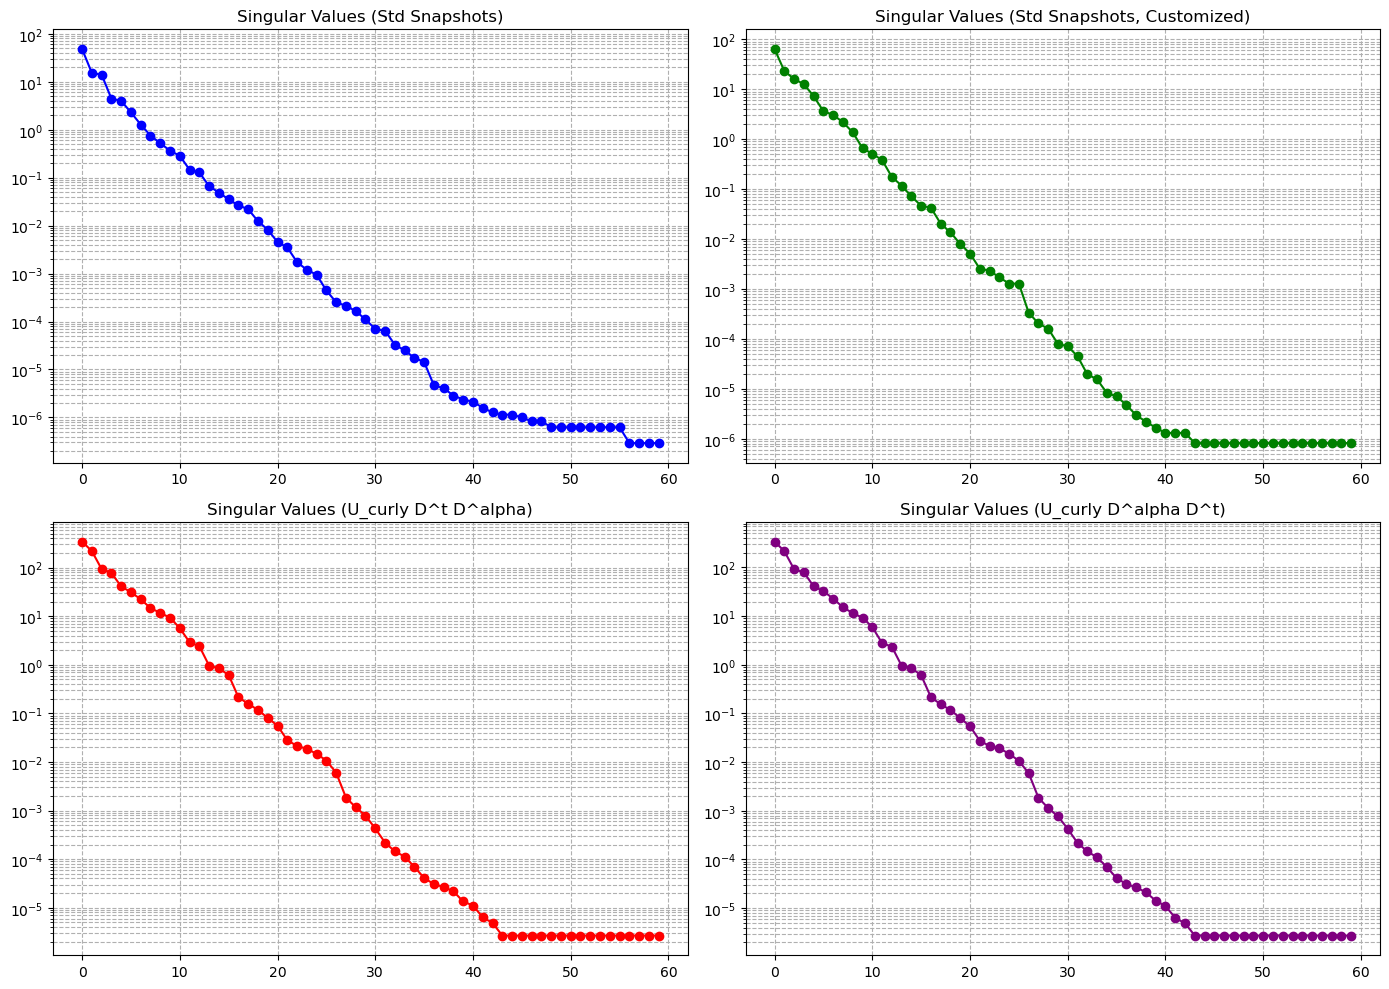

In [7]:
# plot the singular values

import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0, 0].semilogy(std_pod_singular_values, marker='o', color='blue')
axs[0, 0].set_title("Singular Values (Std Snapshots)")
axs[0, 0].grid(True, which="both", ls="--")

axs[0, 1].semilogy(customized_pod_singular_values, marker='o', color='green')
axs[0, 1].set_title("Singular Values (Std Snapshots, Customized)")
axs[0, 1].grid(True, which="both", ls="--")

axs[1, 0].semilogy(U_DaDt_pod_singular_values, marker='o', color='red')
axs[1, 0].set_title("Singular Values (U_curly D^t D^alpha)")
axs[1, 0].grid(True, which="both", ls="--")

axs[1, 1].semilogy(U_DtDa_pod_singular_values, marker='o', color='purple')
axs[1, 1].set_title("Singular Values (U_curly D^alpha D^t)")
axs[1, 1].grid(True, which="both", ls="--")

plt.tight_layout()
plt.show()

In [8]:
# construct ROM using std 

from pymor.reductors.parabolic import ParabolicRBReductor

reductor_std = ParabolicRBReductor(
       fom=fom,
       RB=std_pod_basis,
       product=fom.h1_0_semi_product,
       coercivity_estimator=None,
       check_orthonormality=False,
       check_tol=None
   )

beta= 3.75
r=20
rom_std_r = reductor_std.reduce(dims={'RB': r})   # create r-dim rom
u_rom_std = rom_std_r.solve(beta) # solve rom for this mu in low dim
std_rom_rec = reductor_std.reconstruct(u_rom_std) # back to high dim

len(std_rom_rec)


Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

301

In [9]:
# construct ROM using curly U DtDa

from pymor.reductors.parabolic import ParabolicRBReductor

reductor_U_DtDa = ParabolicRBReductor(
       fom=fom,
       RB=U_DtDa_pod_basis,
       product=fom.h1_0_semi_product,
       coercivity_estimator=None,
       check_orthonormality=False,
       check_tol=None
   )

beta= 3.75
r=r
rom_DtDa = reductor_U_DtDa.reduce(dims={'RB': r})   # create r-dim rom
u_rom_DtDa = rom_DtDa.solve(beta) # solve rom for this mu in low dim
DtDa_rom_rec = reductor_U_DtDa.reconstruct(u_rom_DtDa) # back to high dim

len(DtDa_rom_rec)

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

301

In [10]:
# construct ROM using curly U DaDt

from pymor.reductors.parabolic import ParabolicRBReductor

reductor_U_DaDt = ParabolicRBReductor(
       fom=fom,
       RB=U_DaDt_pod_basis,
       product=fom.h1_0_semi_product,
       coercivity_estimator=None,
       check_orthonormality=False,
       check_tol=None
   )

beta= 3.75
r=r
rom_DaDt = reductor_U_DaDt.reduce(dims={'RB': r})   # create r-dim rom
u_rom_DaDt = rom_DaDt.solve(beta) # solve rom for this mu in low dim
DaDt_rom_rec = reductor_U_DaDt.reconstruct(u_rom_DaDt) # back to high dim

len(DaDt_rom_rec)

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

301

In [ ]:
# # construct customized ROM using std 

# from pymor.reductors.parabolic import ParabolicRBReductor

# data = parameterstudy[beta]
# T_per = data['period']
# u0_array = data['initial_data']

# fom_customized = create_fom(nt=300, h=50, time=30, initial_array=u0_array)

# RB_numpy = std_pod_basis.to_numpy()
# RB_compatible = fom_customized.solution_space.from_numpy(RB_numpy)

# reductor_std_customized = ParabolicRBReductor(
#     fom=fom_customized,     
#     RB=RB_compatible,         
#     product=fom_customized.products['h1_0_semi'],
#     coercivity_estimator=None,
#     check_orthonormality=False,
#     check_tol=None
# )

# r = 40
# rom_std_r = reductor_std_customized.reduce(dims={'RB': r})   
# u_rom_std = rom_std_r.solve(beta) 
# customized_rom_rec = reductor_std.reconstruct(u_rom_std) 

# len(customized_rom_rec)

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

701

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

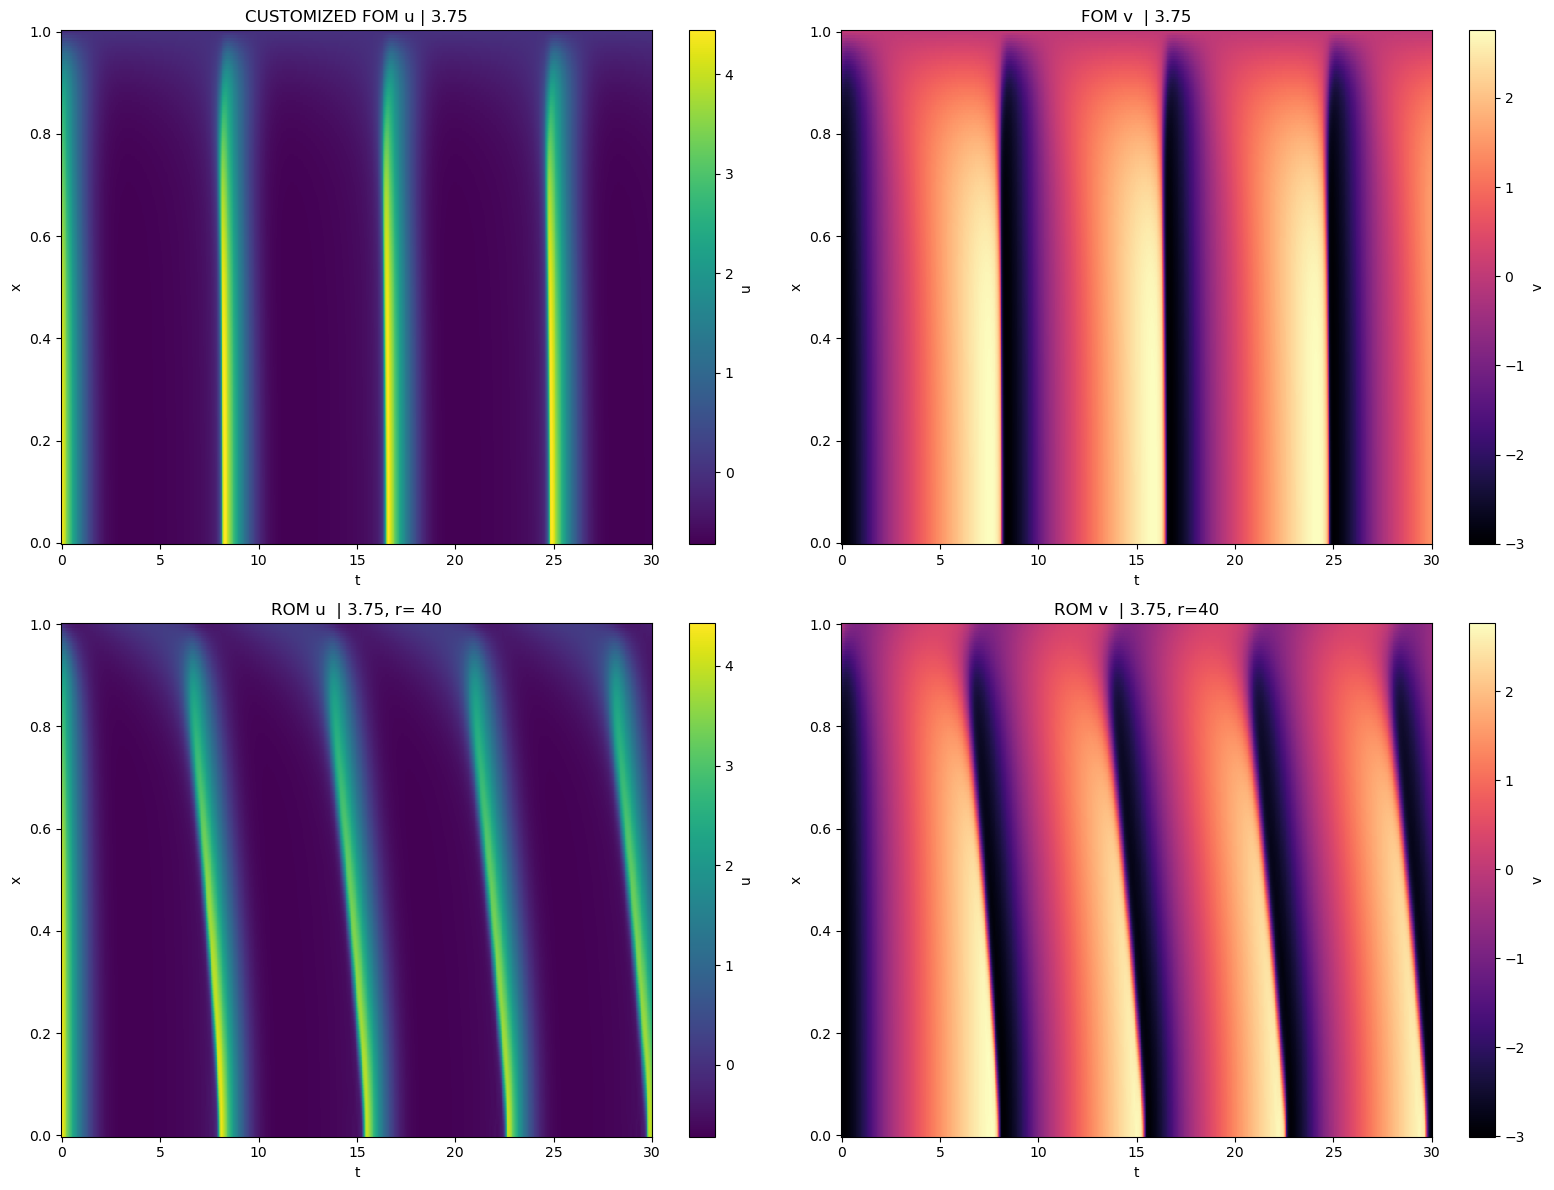

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

NameError: name 'U_rom_rec' is not defined

In [ ]:
# # plot für customized


# # compute customized fom solution

# data = parameterstudy[beta]
# T_per = data['period']
# u0_array = data['initial_data']

# fom_snapshot = create_fom(nt=700, h=50, time=30, initial_array=u0_array) # customized fom
    
# U_trajectory = fom_snapshot.solve(beta)

# len(U_trajectory)

# V_h = fom.operator.V_h
# mesh = V_h.mesh
# x_werte = np.linspace(0, 1, 200)
# gfu_plot = GridFunction(V_h)

# num_x_points = 200
# num_t_points = len(U_rom_rec) 

# x_werte = np.linspace(0, 1, num_x_points)
# t_werte = np.linspace(0, fom.T, num_t_points)

# u_matrix_rom = np.zeros((num_x_points, num_t_points))
# v_matrix_rom = np.zeros((num_x_points, num_t_points))

# u_matrix_fom = np.zeros((num_x_points, num_t_points))
# v_matrix_fom = np.zeros((num_x_points, num_t_points))

# gfu_plot = GridFunction(V_h)

# for t_idx in range(num_t_points):
   
#     vec_pymor_rom = U_rom_rec[t_idx].vectors[0].real_part
#     gfu_plot.vec.data = vec_pymor_rom.impl.vec 
    
#     u_matrix_rom[:, t_idx] = [gfu_plot.components[0](mesh(x)) for x in x_werte]
#     v_matrix_rom[:, t_idx] = [gfu_plot.components[1](mesh(x)) for x in x_werte]

#     vec_pymor_fom = U_trajectory[t_idx].vectors[0].real_part
#     gfu_plot.vec.data = vec_pymor_fom.impl.vec 
    
#     u_matrix_fom[:, t_idx] = [gfu_plot.components[0](mesh(x)) for x in x_werte]
#     v_matrix_fom[:, t_idx] = [gfu_plot.components[1](mesh(x)) for x in x_werte]

# T, X = np.meshgrid(t_werte, x_werte)

# fig, axs = plt.subplots(2, 2, figsize=(16, 12))
# c1 = axs[0, 0].pcolormesh(T, X, u_matrix_fom, cmap='viridis', shading='auto', vmin=None, vmax=None)
# axs[0, 0].set_title(f"CUSTOMIZED FOM u | {beta}")
# axs[0, 0].set_xlabel("t")
# axs[0, 0].set_ylabel("x")
# fig.colorbar(c1, ax=axs[0, 0], label="u")

# c2 = axs[0, 1].pcolormesh(T, X, v_matrix_fom, cmap='magma', shading='auto', vmin=None, vmax=None)
# axs[0, 1].set_title(f"FOM v  | {beta}")
# axs[0, 1].set_xlabel("t")
# axs[0, 1].set_ylabel("x")
# fig.colorbar(c2, ax=axs[0, 1], label="v")

# c3 = axs[1, 0].pcolormesh(T, X, u_matrix_rom, cmap='viridis', shading='auto', vmin=None, vmax=None)
# axs[1, 0].set_title(f"ROM u  | {beta}, r= {r}")
# axs[1, 0].set_xlabel("t")
# axs[1, 0].set_ylabel("x")
# fig.colorbar(c3, ax=axs[1, 0], label="u")

# c4 = axs[1, 1].pcolormesh(T, X, v_matrix_rom, cmap='magma', shading='auto', vmin=None, vmax=None)
# axs[1, 1].set_title(f"ROM v  | {beta}, r={r}")
# axs[1, 1].set_xlabel("t")
# axs[1, 1].set_ylabel("x")
# fig.colorbar(c4, ax=axs[1, 1], label="v")
# plt.tight_layout()
# plt.show()

In [12]:
# not customized reference solution

V_h = fom.operator.V_h
mesh = V_h.mesh
x_werte = np.linspace(0, 1, 200)
gfu_plot = GridFunction(V_h)

U_trajectory1 = fom.solve(beta)  # compute not-customized fom solution

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

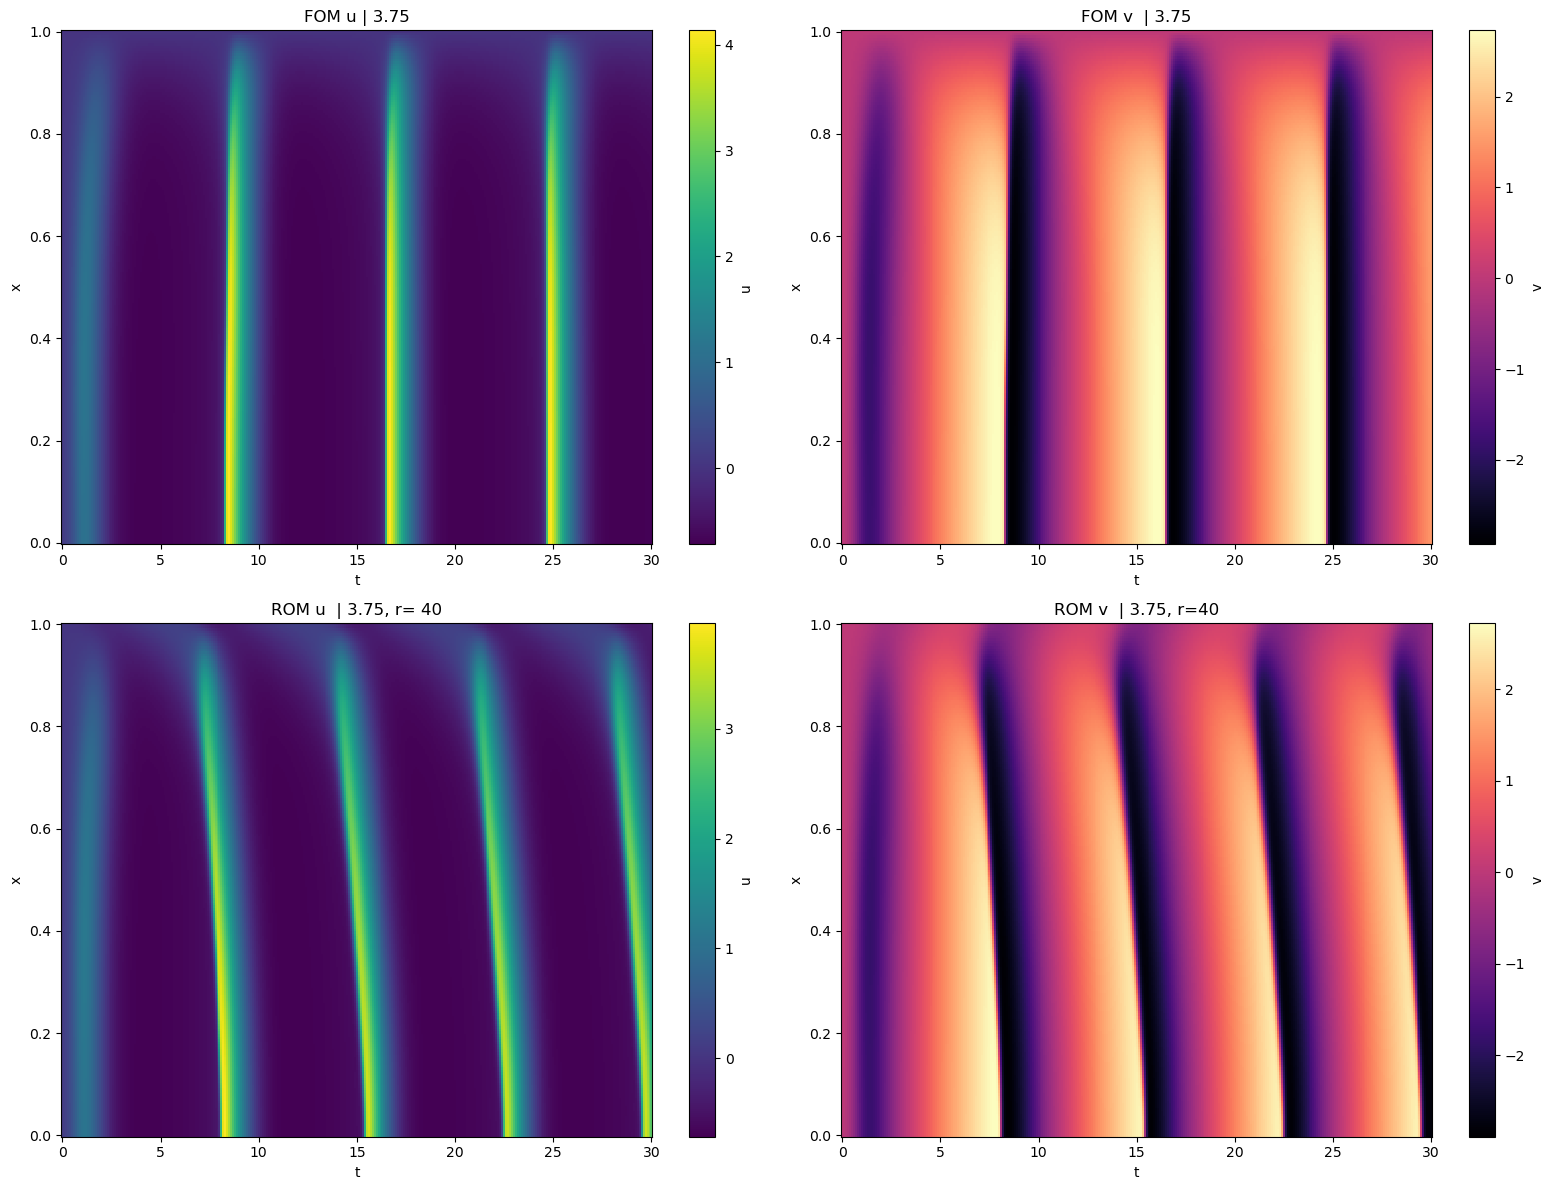

In [41]:
# plot für nicht customized

num_x_points = 200
num_t_points = len(std_rom_rec) 

x_werte = np.linspace(0, 1, num_x_points)
t_werte = np.linspace(0, fom.T, num_t_points)

u_matrix_rom = np.zeros((num_x_points, num_t_points))
v_matrix_rom = np.zeros((num_x_points, num_t_points))

u_matrix_fom = np.zeros((num_x_points, num_t_points))
v_matrix_fom = np.zeros((num_x_points, num_t_points))

gfu_plot = GridFunction(V_h)

for t_idx in range(num_t_points):
   
    vec_pymor_rom = std_rom_rec[t_idx].vectors[0].real_part
    gfu_plot.vec.data = vec_pymor_rom.impl.vec 
    
    u_matrix_rom[:, t_idx] = [gfu_plot.components[0](mesh(x)) for x in x_werte]
    v_matrix_rom[:, t_idx] = [gfu_plot.components[1](mesh(x)) for x in x_werte]

    vec_pymor_fom = U_trajectory1[t_idx].vectors[0].real_part
    gfu_plot.vec.data = vec_pymor_fom.impl.vec 
    
    u_matrix_fom[:, t_idx] = [gfu_plot.components[0](mesh(x)) for x in x_werte]
    v_matrix_fom[:, t_idx] = [gfu_plot.components[1](mesh(x)) for x in x_werte]

T, X = np.meshgrid(t_werte, x_werte)

fig, axs = plt.subplots(2, 2, figsize=(16, 12))

c1 = axs[0, 0].pcolormesh(T, X, u_matrix_fom, cmap='viridis', shading='auto', vmin=None, vmax=None)
axs[0, 0].set_title(f"FOM u | {beta}")
axs[0, 0].set_xlabel("t")
axs[0, 0].set_ylabel("x")
fig.colorbar(c1, ax=axs[0, 0], label="u")

c2 = axs[0, 1].pcolormesh(T, X, v_matrix_fom, cmap='magma', shading='auto', vmin=None, vmax=None)
axs[0, 1].set_title(f"FOM v  | {beta}")
axs[0, 1].set_xlabel("t")
axs[0, 1].set_ylabel("x")
fig.colorbar(c2, ax=axs[0, 1], label="v")

c3 = axs[1, 0].pcolormesh(T, X, u_matrix_rom, cmap='viridis', shading='auto', vmin=None, vmax=None)
axs[1, 0].set_title(f"ROM u  | {beta}, r= {r}")
axs[1, 0].set_xlabel("t")
axs[1, 0].set_ylabel("x")
fig.colorbar(c3, ax=axs[1, 0], label="u")

c4 = axs[1, 1].pcolormesh(T, X, v_matrix_rom, cmap='magma', shading='auto', vmin=None, vmax=None)
axs[1, 1].set_title(f"ROM v  | {beta}, r={r}")
axs[1, 1].set_xlabel("t")
axs[1, 1].set_ylabel("x")
fig.colorbar(c4, ax=axs[1, 1], label="v")
#plt.savefig('test rom nt=100.pdf', bbox_inches='tight')  # save figure
plt.tight_layout()
plt.show()

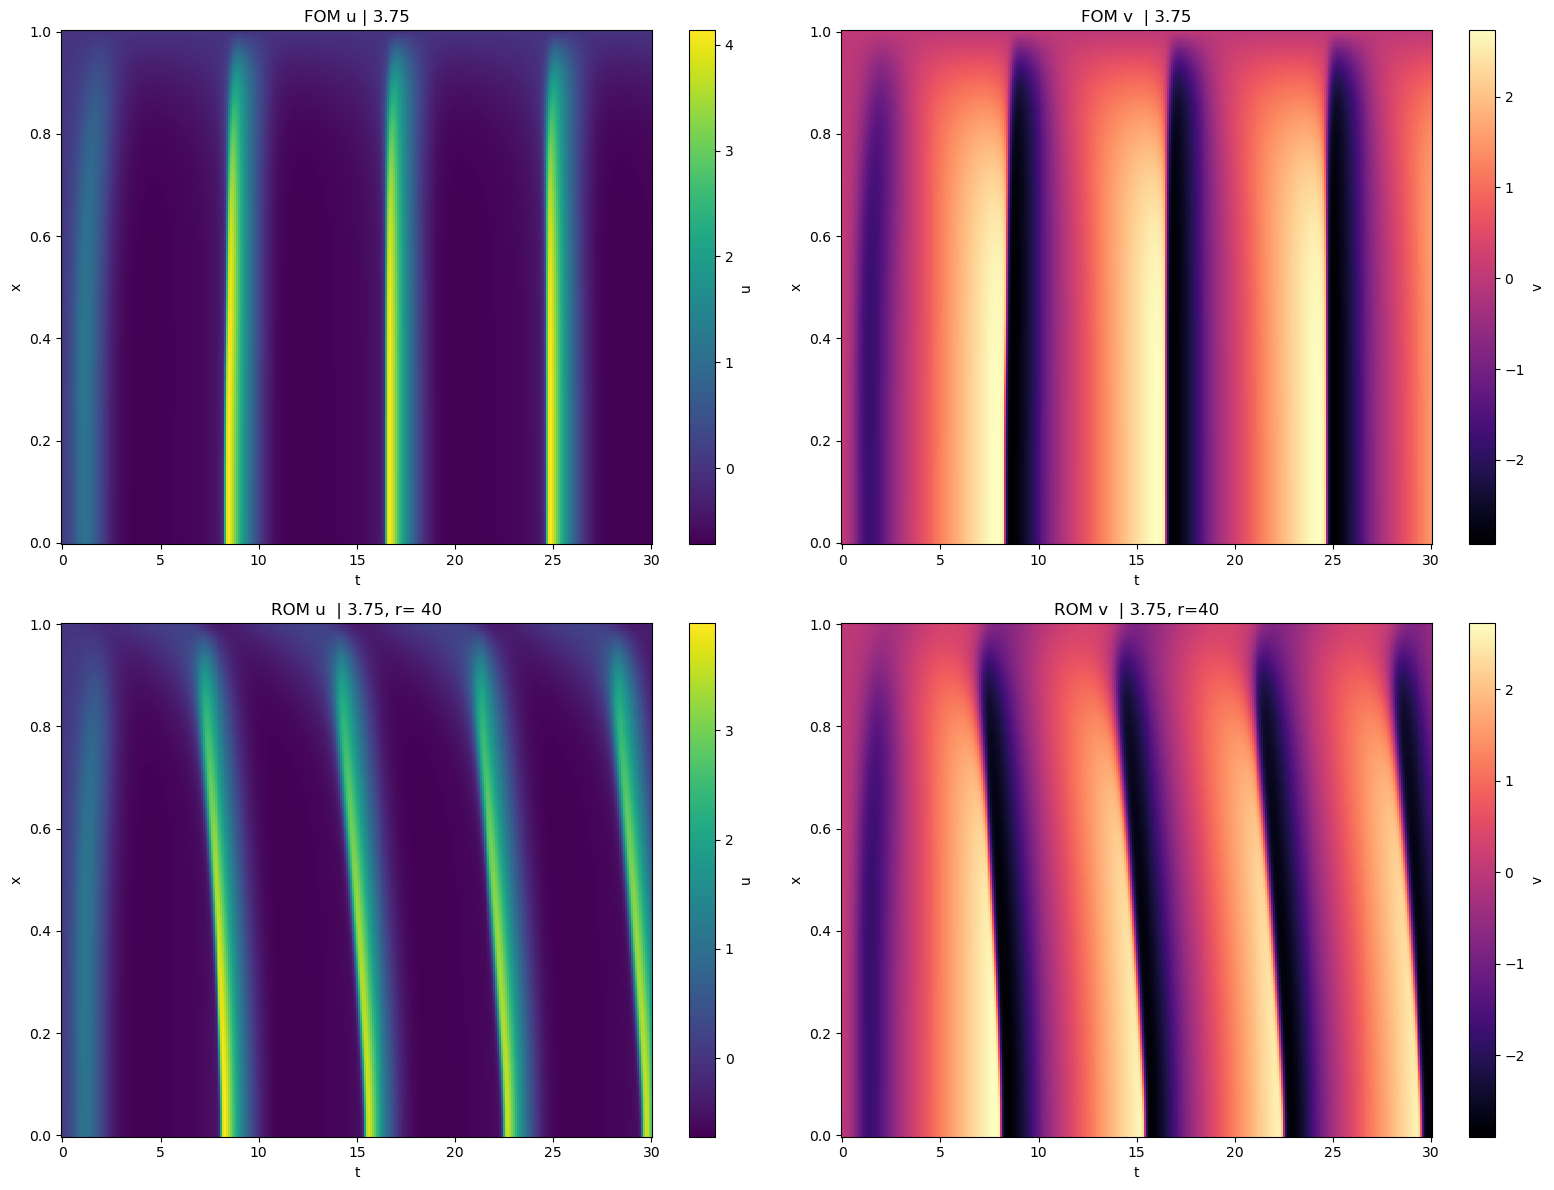

In [45]:
# plot für nicht customized

num_x_points = 200
num_t_points = len(std_rom_rec) 

x_werte = np.linspace(0, 1, num_x_points)
t_werte = np.linspace(0, fom.T, num_t_points)

u_matrix_rom = np.zeros((num_x_points, num_t_points))
v_matrix_rom = np.zeros((num_x_points, num_t_points))

u_matrix_fom = np.zeros((num_x_points, num_t_points))
v_matrix_fom = np.zeros((num_x_points, num_t_points))

gfu_plot = GridFunction(V_h)

for t_idx in range(num_t_points):
   
    vec_pymor_rom = DtDa_rom_rec[t_idx].vectors[0].real_part
    gfu_plot.vec.data = vec_pymor_rom.impl.vec 
    
    u_matrix_rom[:, t_idx] = [gfu_plot.components[0](mesh(x)) for x in x_werte]
    v_matrix_rom[:, t_idx] = [gfu_plot.components[1](mesh(x)) for x in x_werte]

    vec_pymor_fom = U_trajectory1[t_idx].vectors[0].real_part
    gfu_plot.vec.data = vec_pymor_fom.impl.vec 
    
    u_matrix_fom[:, t_idx] = [gfu_plot.components[0](mesh(x)) for x in x_werte]
    v_matrix_fom[:, t_idx] = [gfu_plot.components[1](mesh(x)) for x in x_werte]

T, X = np.meshgrid(t_werte, x_werte)

fig, axs = plt.subplots(2, 2, figsize=(16, 12))

c1 = axs[0, 0].pcolormesh(T, X, u_matrix_fom, cmap='viridis', shading='auto', vmin=None, vmax=None)
axs[0, 0].set_title(f"FOM u | {beta}")
axs[0, 0].set_xlabel("t")
axs[0, 0].set_ylabel("x")
fig.colorbar(c1, ax=axs[0, 0], label="u")

c2 = axs[0, 1].pcolormesh(T, X, v_matrix_fom, cmap='magma', shading='auto', vmin=None, vmax=None)
axs[0, 1].set_title(f"FOM v  | {beta}")
axs[0, 1].set_xlabel("t")
axs[0, 1].set_ylabel("x")
fig.colorbar(c2, ax=axs[0, 1], label="v")

c3 = axs[1, 0].pcolormesh(T, X, u_matrix_rom, cmap='viridis', shading='auto', vmin=None, vmax=None)
axs[1, 0].set_title(f"ROM u  | {beta}, r= {r}")
axs[1, 0].set_xlabel("t")
axs[1, 0].set_ylabel("x")
fig.colorbar(c3, ax=axs[1, 0], label="u")

c4 = axs[1, 1].pcolormesh(T, X, v_matrix_rom, cmap='magma', shading='auto', vmin=None, vmax=None)
axs[1, 1].set_title(f"ROM v  | {beta}, r={r}")
axs[1, 1].set_xlabel("t")
axs[1, 1].set_ylabel("x")
fig.colorbar(c4, ax=axs[1, 1], label="v")
#plt.savefig('test rom nt=100.pdf', bbox_inches='tight')  # save figure
plt.tight_layout()
plt.show()

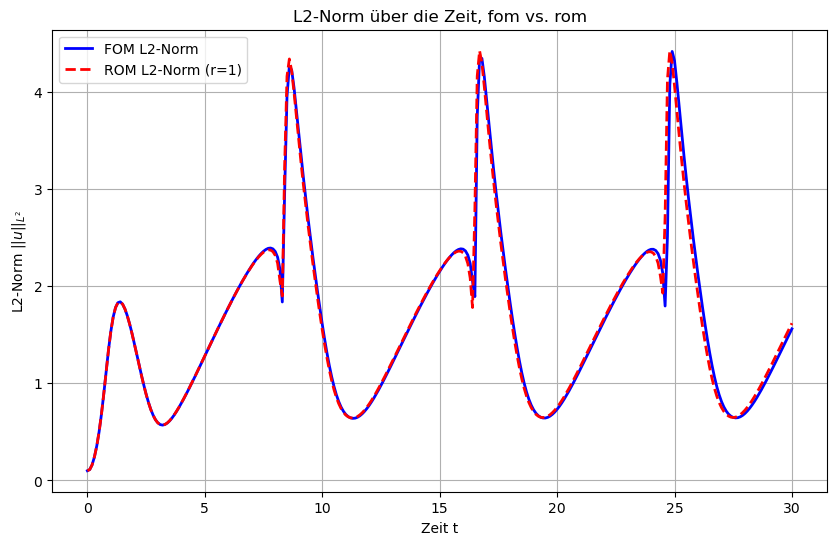

In [16]:
import matplotlib.pyplot as plt

norm_fom = U_trajectory1.norm(fom.products['l2'])
norm_rom = std_rom_rec.norm(fom.products['l2'])


t_werte = np.linspace(0, fom.T, len(norm_fom))
plt.figure(figsize=(10, 6))
plt.plot(t_werte, norm_fom, label='FOM L2-Norm', color='blue', linewidth=2)
plt.plot(t_werte, norm_rom, label=f'ROM L2-Norm (r={r})', color='red', linestyle='dashed', linewidth=2)

plt.title('L2-Norm über die Zeit, fom vs. rom')
plt.xlabel('Zeit t')
plt.ylabel('L2-Norm $||u||_{L^2}$')
plt.legend()
plt.grid(True)
plt.show()

In [22]:
import numpy as np

max_r = 30
r_values = list(range(1, max_r + 1, 5))

errors_std = []
errors_proj_std = []
errors_DaDt = []
errors_proj_DaDt = []

print(f"Start beta={beta}...")

for r in r_values:
    print(f"r={r}...")
    # std method
    rom_r_std = reductor_std.reduce(dims={'RB': r})
    u_rom_std = rom_r_std.solve(beta)
    u_rec_std = reductor_std.reconstruct(u_rom_std)
    
    err_std = np.max((U_trajectory1 - u_rec_std).norm(fom.products['h1_0_semi']))
    errors_std.append(err_std)
    
    # projection error
    basis_std_r = std_pod_basis[:r]
    coeffs_std = fom.products['h1_0_semi'].apply2(basis_std_r, U_trajectory1)
    u_projected_std = basis_std_r.lincomb(coeffs_std) 
    
    err_proj_std = np.max((U_trajectory1 - u_projected_std).norm(fom.products['h1_0_semi']))
    errors_proj_std.append(err_proj_std)

    

Start beta=3.75...
r=1...


Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

r=6...
r=11...
r=16...
r=21...
r=26...


In [24]:
# new method 
for r in r_values:
    print(f"r={r}...")
    rom_r_DaDt = reductor_U_DaDt.reduce(dims={'RB': r})
    u_rom_DaDt = rom_r_DaDt.solve(beta)
    u_rec_DaDt = reductor_U_DaDt.reconstruct(u_rom_DaDt)
    
   
    err_DaDt = np.max((U_trajectory1 - u_rec_DaDt).norm(fom.products['h1_0_semi']))
    errors_DaDt.append(err_DaDt)
    
    # proj error
    basis_DaDt_r = U_DaDt_pod_basis[:r]
    coeffs_DaDt = fom.products['h1_0_semi'].apply2(basis_DaDt_r, U_trajectory1)
    u_projected_DaDt = basis_DaDt_r.lincomb(coeffs_DaDt)
    
    err_proj_DaDt = np.max((U_trajectory1 - u_projected_DaDt).norm(fom.products['h1_0_semi']))
    errors_proj_DaDt.append(err_proj_DaDt)

r=1...


Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

r=6...
r=11...
r=16...
r=21...
r=26...


In [28]:
len(r_values)

6

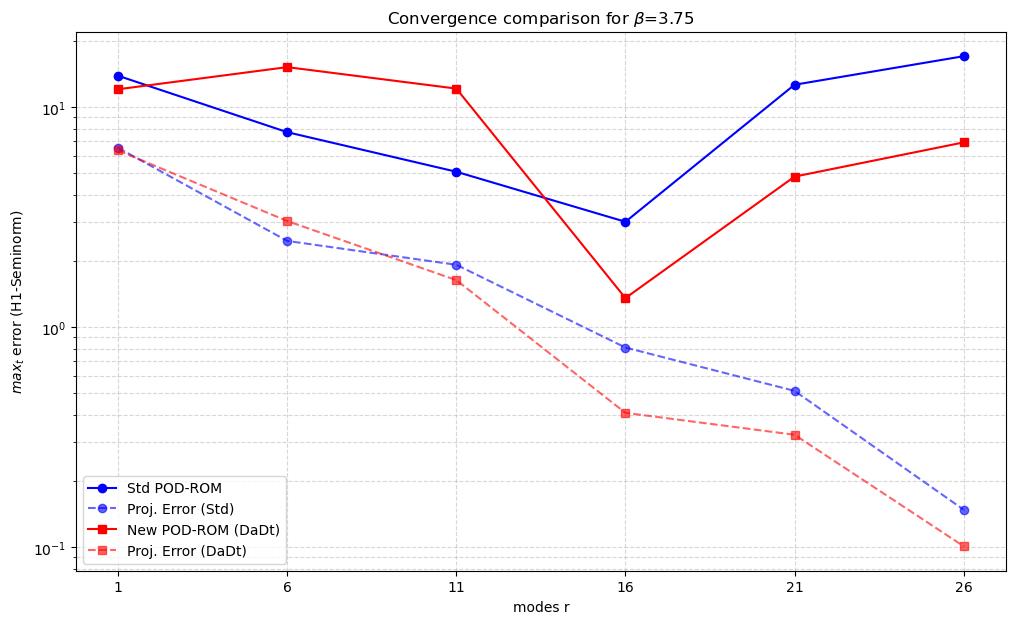

In [29]:
import matplotlib.pyplot as plt


n = len(r_values)

plot_err_std = errors_std[-n:]
plot_err_proj_std = errors_proj_std[-n:]
plot_err_DaDt = errors_DaDt[-n:]
plot_err_proj_DaDt = errors_proj_DaDt[-n:]

plt.figure(figsize=(12, 7))

plt.semilogy(r_values, plot_err_std, 'b-o', label='Std POD-ROM')
plt.semilogy(r_values, plot_err_proj_std, 'b--o', label='Proj. Error (Std)', alpha=0.6)

plt.semilogy(r_values, plot_err_DaDt, 'r-s', label='New POD-ROM (DaDt)')
plt.semilogy(r_values, plot_err_proj_DaDt, 'r--s', label='Proj. Error (DaDt)', alpha=0.6)

plt.xlabel('modes r')
plt.ylabel('$max_{t}$ error (H1-Seminorm)')
plt.title(f'Convergence comparison for $\\beta$={beta}')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.xticks(r_values)
plt.legend()

plt.savefig('heat_H1_max_time_diff_r_both.pdf', bbox_inches='tight')
plt.show()

ValueError: x and y must have same first dimension, but have shapes (6,) and (12,)

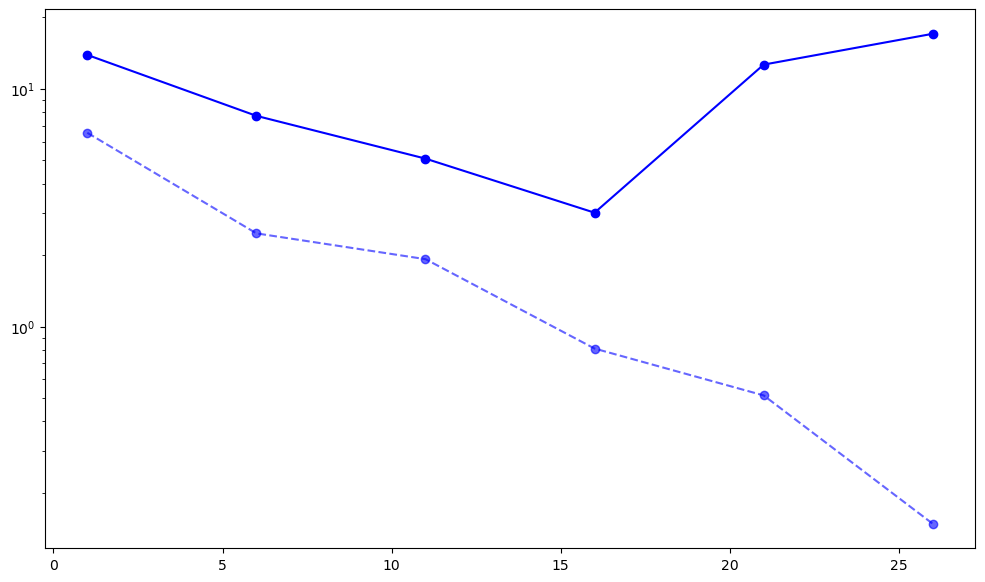

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
plt.semilogy(r_values, errors_std, 'b-o', label='Std POD-ROM')
plt.semilogy(r_values, errors_proj_std, 'b--o', label='Proj. Error (Std)', alpha=0.6)

plt.semilogy(r_values, errors_DaDt, 'r-s', label='New POD-ROM (DaDt)')
plt.semilogy(r_values, errors_proj_DaDt, 'r--s', label='Proj. Error (DaDt)', alpha=0.6)

plt.xlabel('modes r')
plt.ylabel('$max_{t}$ error (H1-Seminorm)')
plt.title(f'Convergence comparison for $\\beta$={beta}')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.xticks(r_values)
plt.legend()

plt.savefig('brusselator_H1_max_time_diff_r_both.pdf', bbox_inches='tight')
plt.show()